<a href="https://colab.research.google.com/github/koko2585/CMAPSS_FD001_1D_ensemble_piecewise_linear_degradation_model.ipynb/blob/main/CMAPSS_FD001_1D_ensemble_piecewise_linear_degradation_model.ipynb%20/notebook/campss_01_EDA_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Setting up enviroment

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from lightgbm import  LGBMRegressor
from xgboost import XGBRegressor

The data are provided as a zip-compressed text file with 26 columns of numbers,
separated by spaces. Each row is a snapshot of data taken during a single operational cycle,
each column is a different variable. The columns correspond to:

1)	unit number
2)	time, in cycles
3)	operational setting 1
4)	operational setting 2
5)	operational setting 3
6)	sensor measurement  1
7)	sensor measurement  2
...
26)	sensor measurement  21


Parameters available to participants as sensor data
|Symbol| Description| Units|
|:---| :--- | :---: |
|T2| Total temperature at fan inlet| |°R|
|T24| Total temperature at LPC outlet |°R
|T30| Total temperature at HPC outlet |°R
|T50 |Total temperature at LPT outlet| °R
|P2 |Pressure at fan inlet |psia
|P15 |Total pressure in bypass-duct |psia
|P30 |Total pressure at HPC outlet |psia
|Nf |Physical fan speed |rpm
|Nc |Physical core speed |rpm
|epr |Engine pressure ratio (P50/P2) |--
|Ps30 |Static pressure at HPC outlet| psia
|phi |Ratio of fuel flow to Ps30| pps/psi
|NRf |Corrected fan speed| rpm
|NRc |Corrected core speed| rpm
|BPR |Bypass Ratio |--
|farB |Burner fuel-air ratio |--
|htBleed| Bleed Enthalpy |--
|Nf_dmd| Demanded fan speed |rpm
|PCNfR_dmd |Demanded corrected fan speed |rpm
|W31| HPT coolant bleed |lbm/s
|W32| LPT coolant bleed |lbm/s


# 2. Loading Data

In [28]:
# Specify features from given data
index_features = ['unit', 'time']
setting_features = ['setting_1', 'setting_2', 'setting_3']
sensor_features = ['T2', 'T24', 'T30', 'T50', 'P2',
                   'P15', 'P30', 'Nf', 'Nc', 'epr', 'Ps30',
                   'phi', 'NRf', 'NRc', 'BPR', 'farB',
                   'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32']

column_names = index_features + setting_features + sensor_features

In [29]:
train_df = pd.read_csv(r"/content/sample_data/train_FD001.txt", delim_whitespace=True, names=column_names, header=None)
test_df = pd.read_csv(r"/content/sample_data/test_FD001.txt", delim_whitespace=True, names=column_names, header=None)
RUL_df = pd.read_csv(r"/content/sample_data/RUL_FD001.txt",delim_whitespace=True, header=None)

train_df.shape, test_df.shape, RUL_df.shape

/tmp/ipykernel_3072/3286365066.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  train_df = pd.read_csv(r"/content/sample_data/train_FD001.txt", delim_whitespace=True, names=column_names, header=None)
/tmp/ipykernel_3072/3286365066.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  test_df = pd.read_csv(r"/content/sample_data/test_FD001.txt", delim_whitespace=True, names=column_names, header=None)
/tmp/ipykernel_3072/3286365066.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  RUL_df = pd.read_csv(r"/content/sample_data/RUL_FD001.txt",delim_whitespace=True, header=None)


((20631, 26), (13096, 26), (100, 1))

# 3. Exploring and prepearing training dataset

In [30]:
train_df.head()

,unit,time,setting_1,setting_2,setting_3,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [31]:
train_df.isnull().sum().sum()

np.int64(0)

In [32]:
train_df.describe()

,unit,time,setting_1,setting_2,setting_3,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,...,0.737553,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [33]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   unit       20631 non-null  int64  
 1   time       20631 non-null  int64  
 2   setting_1  20631 non-null  float64
 3   setting_2  20631 non-null  float64
 4   setting_3  20631 non-null  float64
 5   T2         20631 non-null  float64
 6   T24        20631 non-null  float64
 7   T30        20631 non-null  float64
 8   T50        20631 non-null  float64
 9   P2         20631 non-null  float64
 10  P15        20631 non-null  float64
 11  P30        20631 non-null  float64
 12  Nf         20631 non-null  float64
 13  Nc         20631 non-null  float64
 14  epr        20631 non-null  float64
 15  Ps30       20631 non-null  float64
 16  phi        20631 non-null  float64
 17  NRf        20631 non-null  float64
 18  NRc        20631 non-null  float64
 19  BPR        20631 non-null  float64
 20  farB  

In [34]:
# Finding columns with constant values.
constant_cols = [col for col in train_df.columns if train_df[col].nunique() <= 1]
constant_cols

['setting_3', 'T2', 'P2', 'epr', 'farB', 'Nf_dmd', 'PCNfR_dmd']

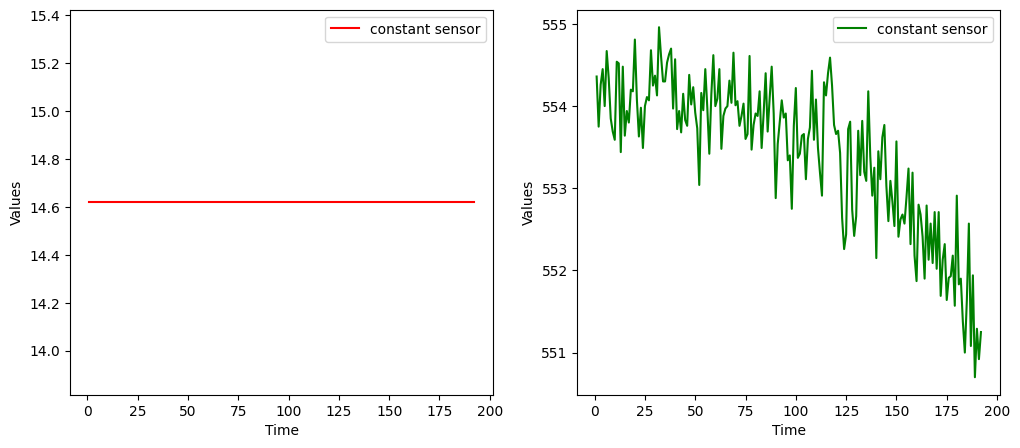

In [35]:
# Comparism plot between constant and varying values in columns.

plt.figure(figsize=(12, 5))
plt.subplot(121)
plt.plot('time', 'P2', data=train_df[train_df['unit'] == 1], color='r', label= 'constant sensor')
plt.xlabel('Time')
plt.ylabel('Values')
plt.legend()

plt.subplot(122)
plt.plot('time', 'P30', data=train_df[train_df['unit'] == 1], color='g', label= 'constant sensor')
plt.xlabel('Time')
plt.ylabel('Values')
plt.legend()

plt.show()

In [36]:
# Dropping columns with constant values.
train_df = train_df.drop(columns=constant_cols)

# Creating Remaining Useful Life (RUL)
    RUL = Tmax - t
    Tmax = maximum time cycle
    t = time cycle step

In [37]:
t_max = train_df.groupby('unit')['time'].max()              # filtering max time cycle for ecah engine units
train_df = train_df.merge(t_max, on='unit', how='left')     # merging t_max values into dataset
train_df['RUL'] = train_df['time_y'] - train_df['time_x']   # specify RUL column
train_df = train_df.drop(columns='time_y')
train_df = train_df.rename(columns={'time_x' : 'time'})
train_df.head()

,unit,time,setting_1,setting_2,T24,T30,T50,P15,P30,Nf,Nc,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,RUL
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187


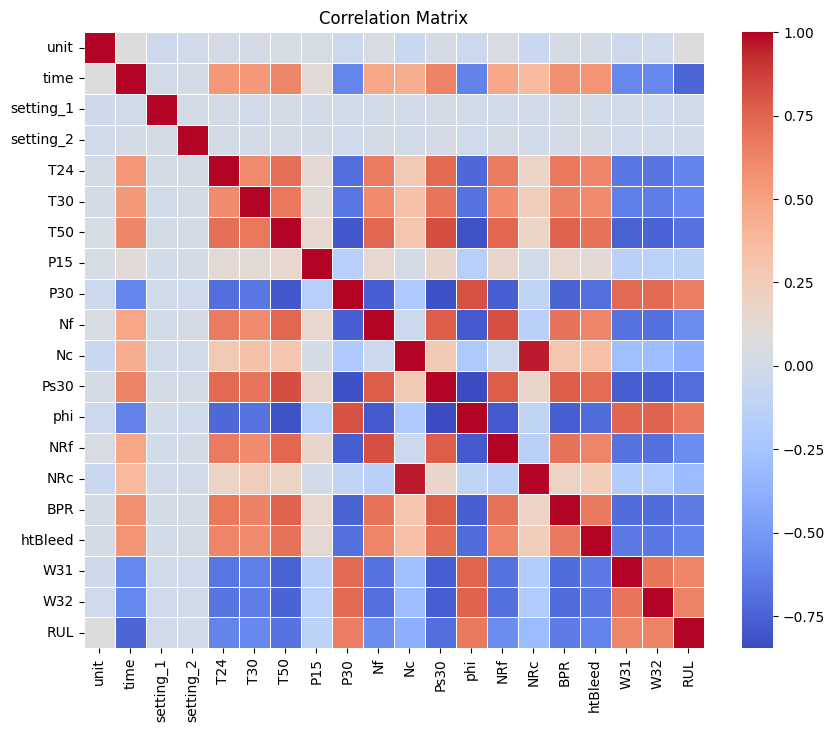

In [38]:
# Correlation matrix
corr_matrix = train_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

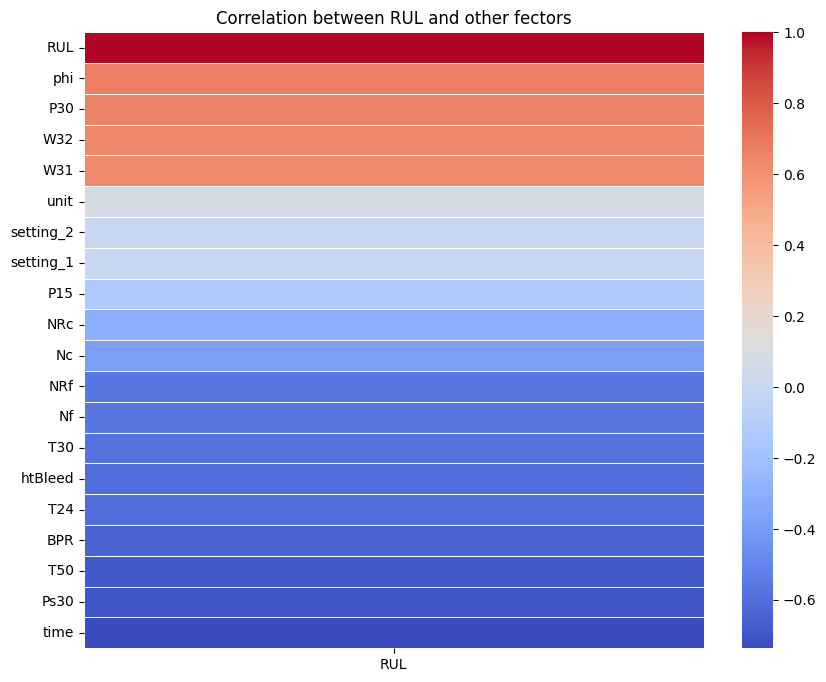

In [39]:
# Correlation between RUL and others
corr_RUL = corr_matrix['RUL'].sort_values(ascending=False).to_frame()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_RUL, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation between RUL and other fectors')
plt.show()

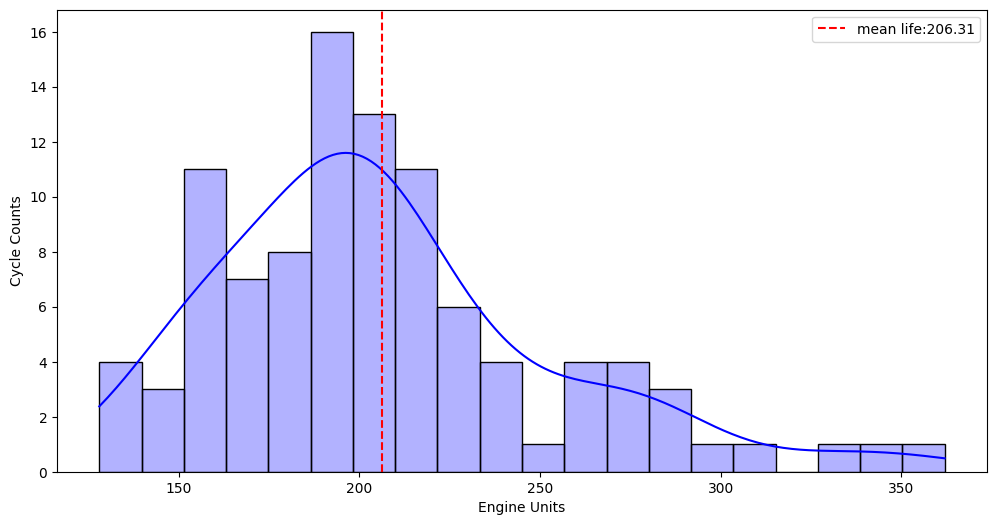

In [40]:
# Engine life distribution
max_life = train_df.groupby('unit')['time'].max()     # max life for each unit

plt.figure(figsize=(12, 6))
sns.histplot(max_life, kde=True, color='b', alpha=0.3, bins=20)
plt.axvline(max_life.mean(), color='r', linestyle='--', label=f'mean life:{max_life.mean()}')
plt.xlabel('Engine Units')
plt.ylabel('Cycle Counts')
plt.legend()
plt.show()

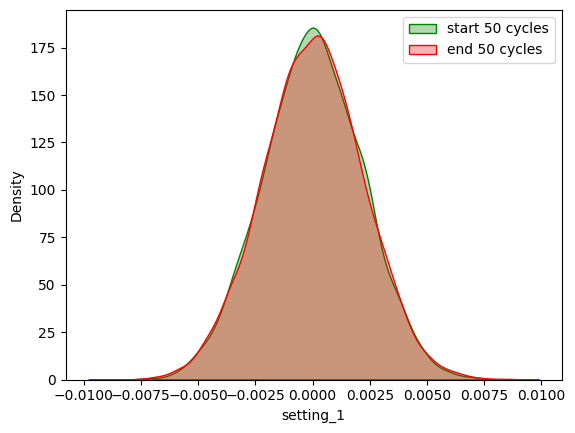

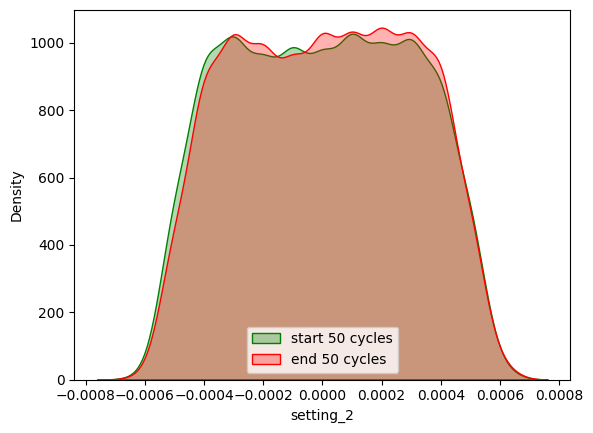

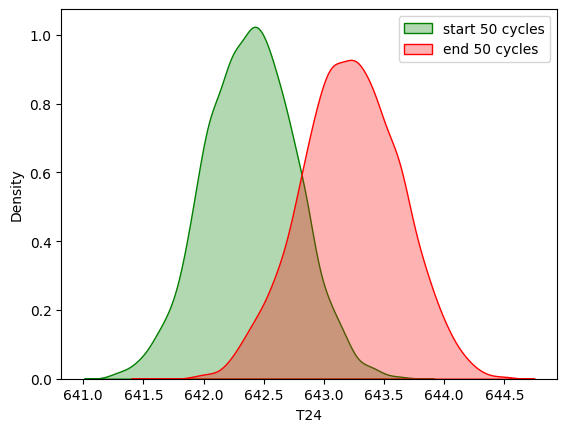

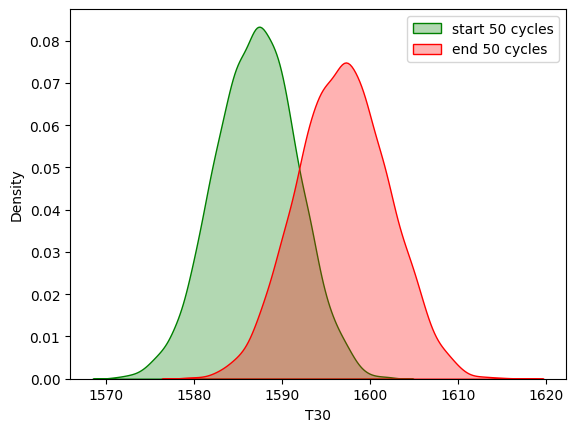

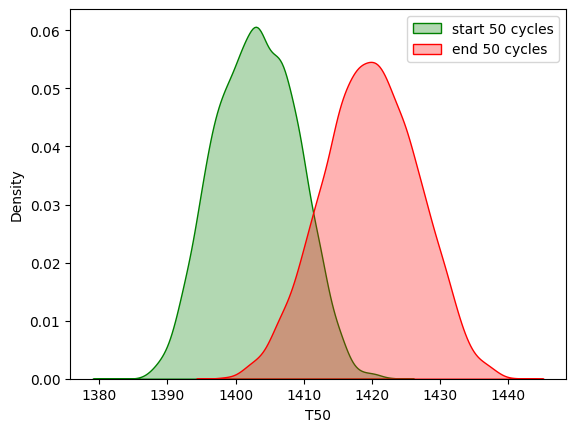

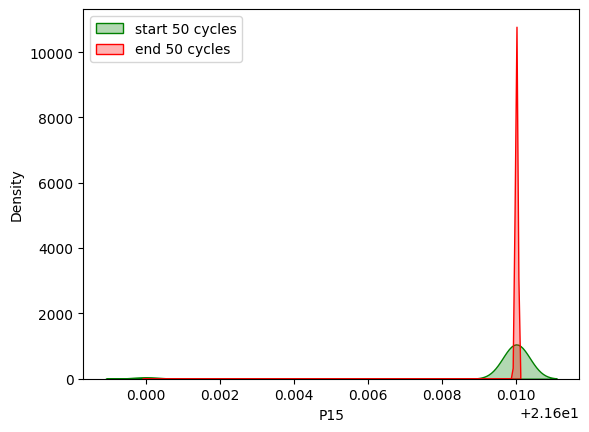

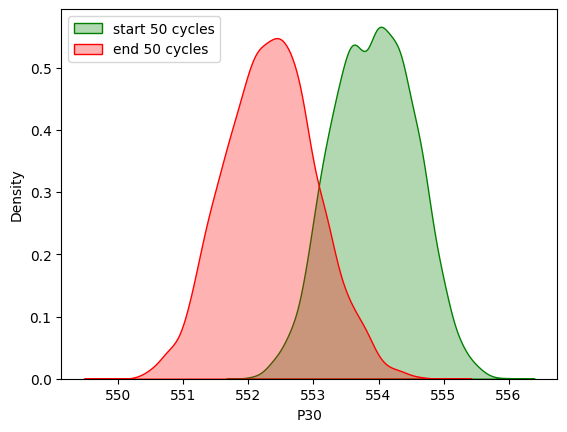

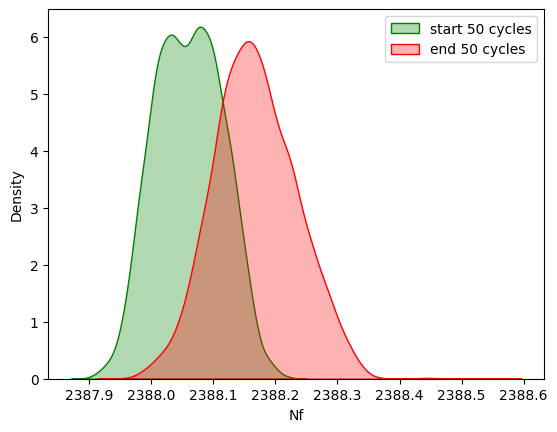

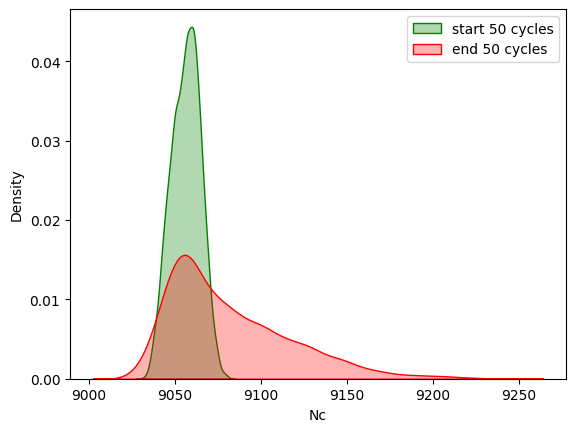

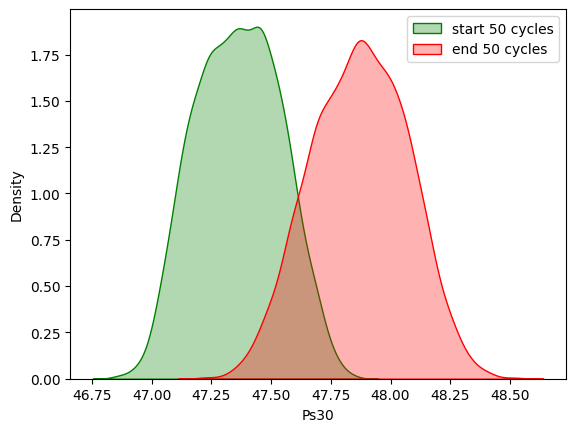

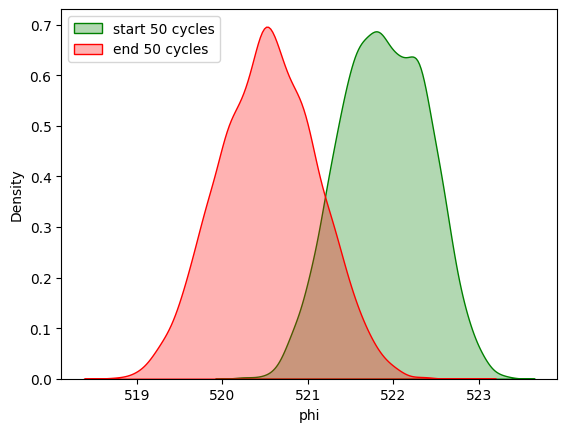

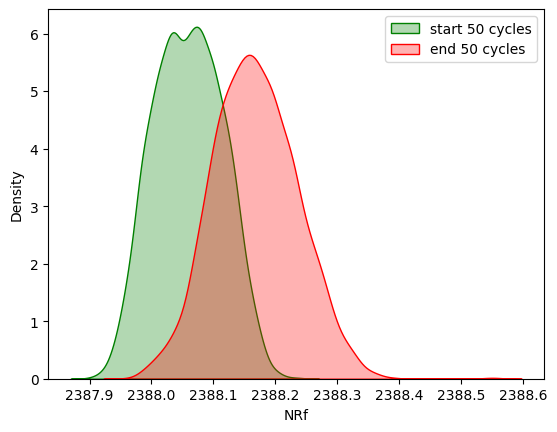

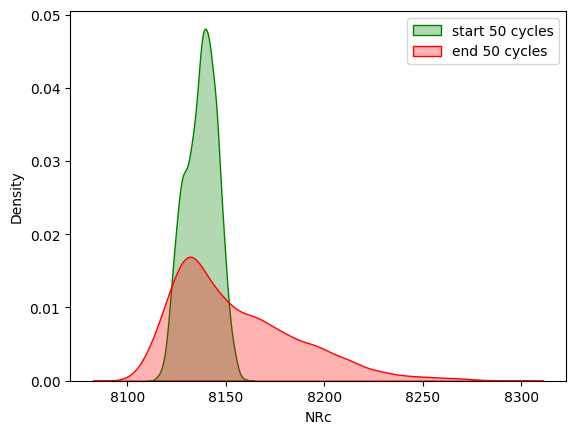

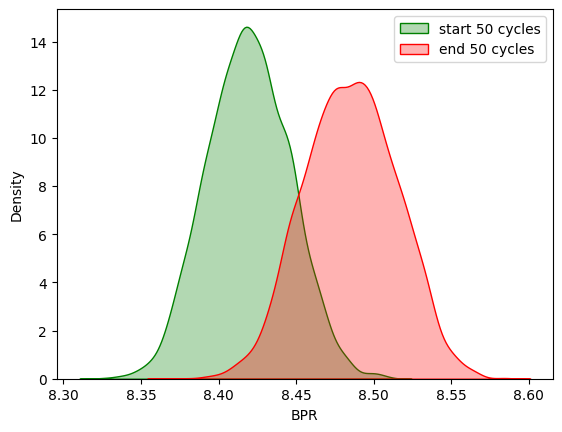

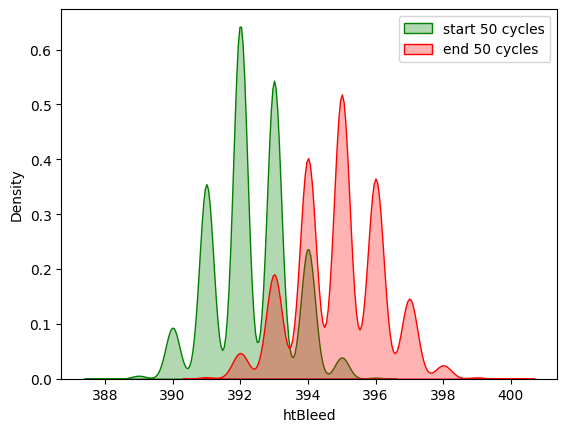

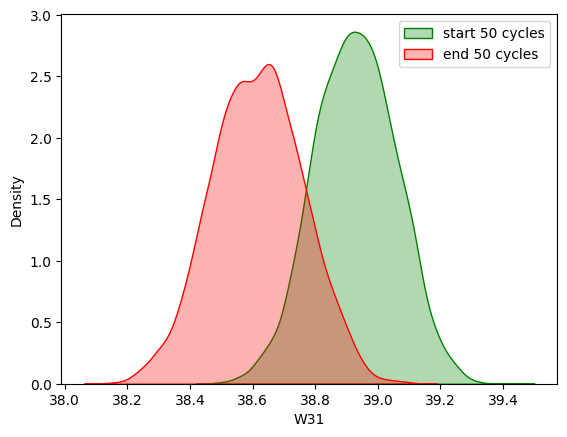

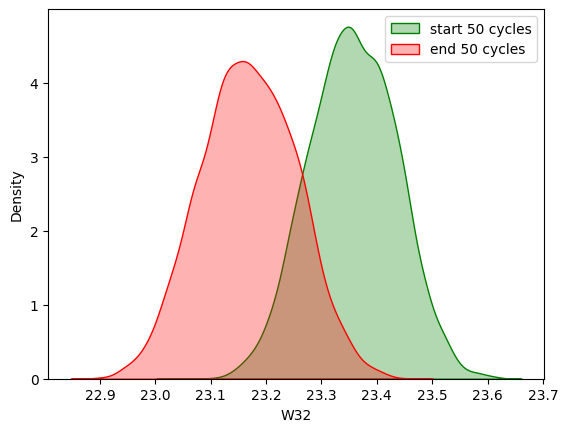

In [41]:
# Behaviours comparism of first and last ten cycles for each features.
start_cycles = train_df[train_df['time'] < 50]
end_cycles = train_df[train_df['RUL'] < 50]

features_to_use = [col for col in train_df.columns if col not in ['unit', 'time', 'RUL']]

def kde_plot(feature):
  sns.kdeplot(start_cycles[feature], fill=True, color='g', alpha=0.3, label='start 50 cycles')
  sns.kdeplot(end_cycles[feature], fill=True, color='r', alpha=0.3, label='end 50 cycles')
  plt.legend()
  plt.show()

for feature in features_to_use:
  kde_plot(feature)


# 4. Data Preparation & Feature Extraction

# Inputs:
    - train_FD001 : Training trajectory data
    - test_FD001  : Test trajectory data
    - RUL_FD001  : True RUL labels for the final test cycles

# Strategy:
    - Target Transformation: RUL values are capped at 125 cycles. This implements
      a piecewise linear RUL model, reflecting the physical reality that engine
      degradation is negligible during early operational life, which prevents the
      model from overestimating early-stage lifespans.
    - Modeling Strategy: Establishing baselines using tree-based ensembles (e.g., Random
      Forest, LightGBM, XGBoost).
    - Preprocessing: Feature scaling will be skipped, as tree-based models are
      invariant to monotonic transformations of the features.

In [42]:
features_to_use = [col for col in train_df.columns if col not in ['unit', 'time', 'RUL']]


X_train = train_df[features_to_use]
y_train = train_df['RUL'].clip(upper=125)

last_cycle_test = test_df.groupby('unit').last().reset_index()    # select last cycle from each unit
X_test = last_cycle_test[features_to_use]
y_test = RUL_df.squeeze().clip(upper=125)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((20631, 17), (100, 17), (20631,), (100,))

# 5. Train and evaluate models.

In [43]:
def model_evaluate(model, X_train, y_train, X_test, y_test, model_name):
  # training the model
  model.fit(X_train, y_train)
  # predicting the model
  y_pred = model.predict(X_test)

  # evaluate the model
  rmse = np.sqrt(mean_squared_error(y_test, y_pred))
  r2 = r2_score(y_test, y_pred)

  # printing results
  print(f"------{model_name}-------")
  print(f"RMSE: {rmse:.2f}")
  print(f"R2: {r2:.2%}")

  # plotting actual and predicted values
  plt.figure(figsize=(12,6))
  plt.plot(y_test, color='r', label='Actual values')
  plt.plot(y_pred, color='y', linestyle='--', label='Predicted values')
  plt.legend()
  plt.show()

------Random Forest-------
RMSE: 17.23
R2: 81.52%


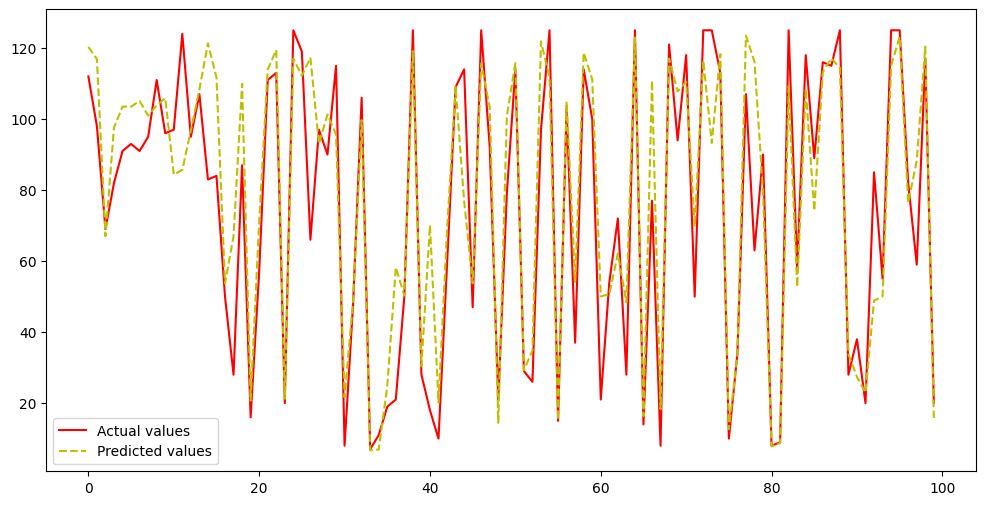

In [44]:
model_rf = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)

_ = model_evaluate(model_rf, X_train, y_train, X_test, y_test, 'Random Forest')

------LightGBM-------
RMSE: 16.99
R2: 82.02%


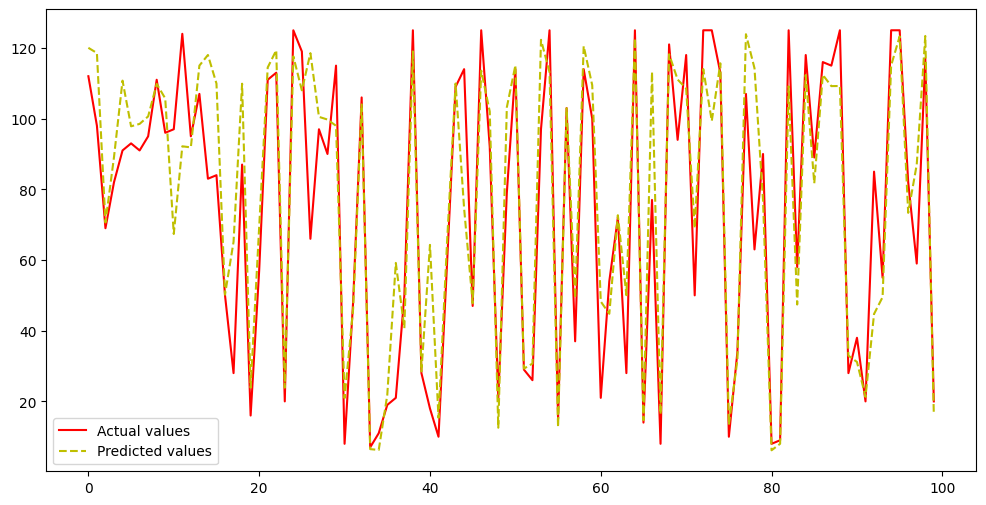

In [45]:
model_lgbm = LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, n_jobs=-1, random_state=42)

_ = model_evaluate(model_lgbm, X_train, y_train, X_test, y_test, 'LightGBM')

------XGBoost-------
RMSE: 17.05
R2: 81.90%


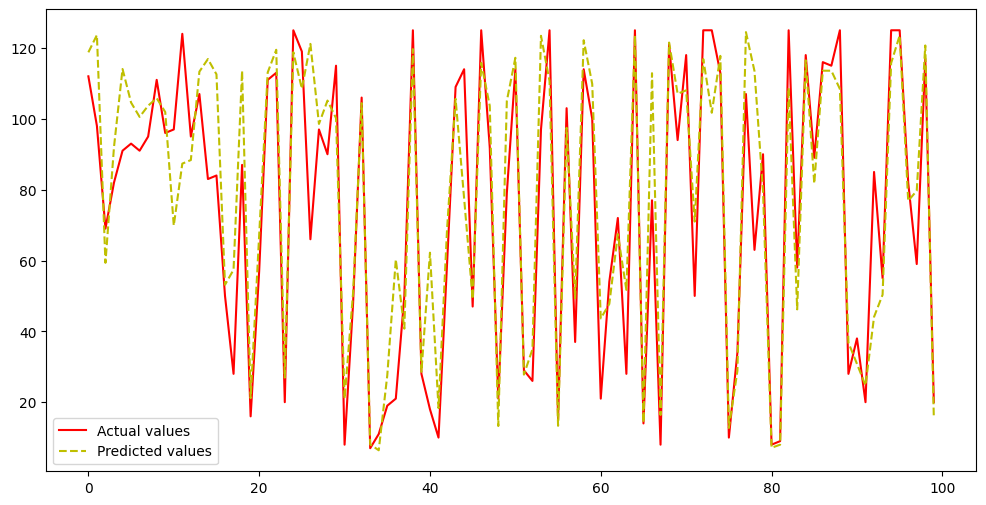

In [46]:
model_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, n_jobs=-1, random_state=42)

_ = model_evaluate(model_xgb, X_train, y_train, X_test, y_test, 'XGBoost')

We evaluated three tree-based ensemble methods—Random Forest, LightGBM, and XGBoost—using identical features and the piecewise linear target (RUL ≤ 125).

  Performance Comparison

|Model|RMSE|R2|
|:---|:---:|:---:|
|Random Forest|17.23 | 81.52|
|LightGBM| 16.99|82.02 |
|XGBoost| 17.05|81.90 |

Conclusion: Moving forward, LightGBM is chosen as our final deployment model. Next steps include fine-tuning its hyperparameters (such as learning rate and regularization) and exploring feature importance to isolate key degradation indicators.

In [47]:
from lightgbm import LGBMRegressor
from scipy.stats import randint, uniform, loguniform
from sklearn.model_selection import GroupKFold, RandomizedSearchCV

# 1. Initialize the LightGBM Regressor
lgbm = LGBMRegressor(random_state=42, n_jobs=1, verbosity=-1)  # Set n_jobs=1 to avoid collision with CV n_jobs

# 2. Define the hyperparameter search space
param_dist = {
    "n_estimators": randint(100, 600),
    "max_depth": randint(3, 12),
    "num_leaves": randint(15, 100),
    "min_child_samples": randint(10, 50),
    "learning_rate": loguniform(0.01, 0.2),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3),
}

# 3. Instantiate GroupKFold (replaces cv=3 integer)
group_kfold = GroupKFold(n_splits=3)

# 4. Configure the randomized search cross-validation
random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=20,
    cv=group_kfold,  # Pass the GroupKFold object here
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,  # Parallelize the CV iterations instead
    verbose=1,
)

# 5. Fit the model (You MUST explicitly provide the groups array here)
random_search.fit(X_train, y_train, groups=train_df['unit'])

# 6. Output the performance results
print("Best CV RMSE:", -random_search.best_score_)
print("\nBest Parameters:")
for key, value in random_search.best_params_.items():
    print(f"{key}: {value}")


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best CV RMSE: 18.28680204783989

Best Parameters:
colsample_bytree: 0.7021198915659151
learning_rate: 0.010715314115595202
max_depth: 5
min_child_samples: 12
n_estimators: 584
num_leaves: 65
subsample: 0.9040922615763338


In [48]:
best_lgbm = random_search.best_estimator_

y_pred = best_lgbm.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.3f}")

MAE : 11.91
RMSE: 16.97
R²  : 0.821


# 5. Model Inference Visualizations

  Select a single engine unit's entire trajectory to evaluate how well
  the trained LightGBM model tracks degradation over time compared to
  the actual piecewise linear RUL target.

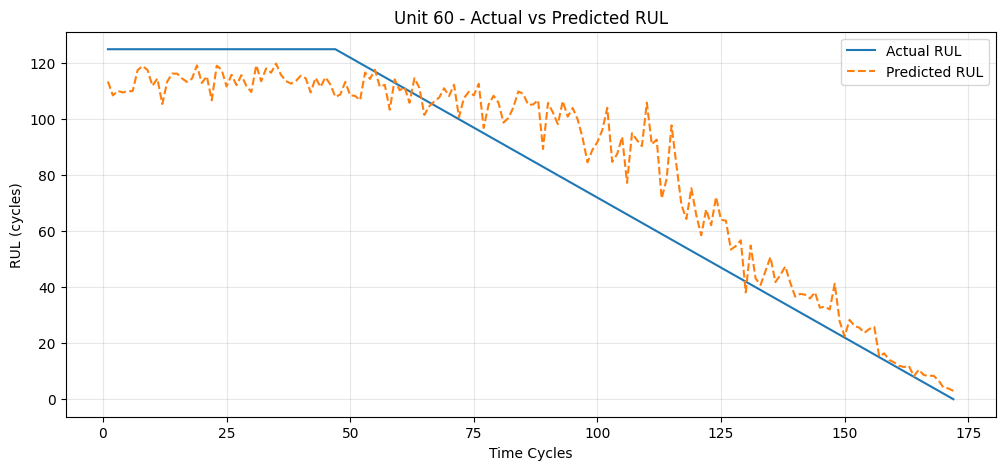

In [50]:
# test plot for random unit last cycle

unit_id = 60

unit_data = train_df[train_df['unit'] == unit_id].copy()

X_unit = unit_data[features_to_use]

y_actual = unit_data['RUL'].clip(upper=125)
y_pred_unit = best_lgbm.predict(X_unit)

plt.figure(figsize=(12, 5))

plt.plot(
    unit_data['time'],
    y_actual,
    label='Actual RUL'
)

plt.plot(
    unit_data['time'],
    y_pred_unit,
    '--',
    label='Predicted RUL'
)

plt.title(f'Unit {unit_id} - Actual vs Predicted RUL')
plt.xlabel('Time Cycles')
plt.ylabel('RUL (cycles)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()